In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib_venn import venn2, venn3
import seaborn as sns
from ALLCools.mcds import MCDS 

In [2]:
# mcds_path = '/ceph/MethDev/pbio/kay/data/Arab10_All_mcds.mcds'
mcds_path = '/ceph/MethDev/pbio/All_mcds.mcds'
rna_path = '/ceph/MethDev/pbio/Arab6_RNA_normalized_data.csv'
meta_path ='/ceph/MethDev/pbio/data/Arab6_cells_and_clusters.csv'

In [3]:
mcds = MCDS.open(mcds_paths = mcds_path, var_dim = 'gene')
rna_matrix = pd.read_csv(rna_path,index_col = 0).T
meta = pd.read_csv(meta_path)
sig_gene = pd.read_csv('/ceph/MethDev/clusters/new_gene_list.txt', header = None)
#re-format and combine clusters
meta['Cell'] = meta['Cell'].str.replace('.','-')
meta = meta.set_index('Cell')
# meta['Cluster'] = meta['Cluster'].replace({6:1,0:1,4:1,5:3})

In [4]:
sig_gene

,0
0,AT1G01410
1,AT1G01550
2,AT1G02110
3,AT1G02260
4,AT1G03140
...,...
1275,ATMG01390
1276,ATMG01400
1277,ATMG01410
1278,ATMG09960


In [5]:
!cp /ceph/MethDev/clusters/new_gene_list.txt /ceph/MethDev/pbio/results

In [4]:
!ls /ceph/MethDev/pbio/results

0413_filtered_exclude2_9_mc_rna_correlation.pdf  mCGN_cluster_zscore.png
0413_filtered_mc_rna_correlation.pdf		 mCGN_frac_Arab10.csv
0413_shuffled_cluster_mc_rna_correlation.pdf	 mCGN_frac.csv
adata_by_leiden.csv				 mCGN_frac_sparse.csv
cluster_corr_custom.csv				 mCGN_frac_sparse_t.csv
cluster_rna_matrix_corrected.csv		 mCGN_std_1.png
cluster_rna_matrix.csv				 mCHN_cluster.png
corr_CGN.pkl					 mc_rna_corr.csv
corr_CHN.pkl					 normalized_expression.csv
df_corr_custom.csv				 rem_2_9_zscore.csv
expression_by_plate_scaled.png			 rem_2_9_zscore_mC.csv
filtered_correlation.pdf			 rem_2_9_zscore_rna.csv
highMCClusterMap.pdf				 rna_df_acute.csv
mc_df_0.5.csv					 rna_df_CGN_acute.csv
mc_df_acute.csv					 rna_df_CGN.csv
mc_df_CGN_acute.csv				 rna_df_CGN_normal.csv
mc_df_CGN.csv					 rna_df_CGN_partial.csv
mc_df_CGN_normal.csv				 rna_df_CGN_test.csv
mc_df_CGN_partial.csv				 rna_df_CHN_0.csv
mc_df_CGN_test.csv				 rna_df_CHN_acute.csv
mc_df_CHN_0.csv					 rna_df_CHN_Acute_partial2.csv
m

In [5]:
#get methylation fraction 
mCGN_mc = mcds.sel(
    mc_type = 'CGN',
    count_type = 'mc').gene_da.to_pandas()
mCGN_cov = mcds.sel(
    mc_type = 'CGN',
    count_type = 'cov').gene_da.to_pandas()
mCGN_frac = mCGN_mc.div(mCGN_cov).fillna(0)

In [6]:
#filter out ATM and ATC genes, then aggregate via sum per cluster
filtered_columns = [col for col in mCGN_mc.columns if 'ATM' not in col and 'ATC' not in col and 'cluster' not in col]

mCGN_mc['cluster'] = meta['Cluster']
mCGN_mc_by_cluster = mCGN_mc.groupby('cluster').sum()[filtered_columns]
mCGN_mc_by_cluster
mCGN_cov['cluster'] = meta['Cluster']
mCGN_cov_by_cluster = mCGN_cov.groupby('cluster').sum()[filtered_columns]

In [7]:
mCGN_frac_by_cluster = mCGN_mc_by_cluster.div(mCGN_cov_by_cluster).fillna(0)
mCGN_frac_by_cluster

gene,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,AT5G67580,AT5G67590,AT5G67600,AT5G67610,AT5G67620,AT5G09945,AT5G67630,AT5G67640,AT5G09955,AT5G09965
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,0.025490,0.069221,0.000000,0.004898,0.597558,0.068908,0.507042,0.133719,0.008969,0.119029,...,0.097147,0.005017,0.003882,0.146733,0.006708,0.000000,0.079179,0.005377,0.006361,0.003486
1.0,0.028993,0.057388,0.009804,0.006477,0.603006,0.060901,0.518519,0.131061,0.004748,0.114884,...,0.101418,0.002966,0.004318,0.153587,0.007095,0.000000,0.071560,0.006052,0.010526,0.002725
2.0,0.032244,0.058621,0.027027,0.004906,0.621651,0.092033,0.493976,0.131535,0.007092,0.120173,...,0.086188,0.002346,0.009202,0.149219,0.007316,0.000000,0.080207,0.006472,0.023392,0.003690
3.0,0.034498,0.048050,0.000000,0.005613,0.614978,0.083645,0.582278,0.131068,0.002392,0.128700,...,0.110066,0.005741,0.005059,0.126192,0.006215,0.000000,0.077694,0.003205,0.019391,0.005968
4.0,0.025919,0.064257,0.000000,0.004799,0.604484,0.062181,0.533333,0.130783,0.006623,0.135154,...,0.104617,0.006182,0.001983,0.121053,0.007403,0.000000,0.069497,0.002721,0.003145,0.010604
5.0,0.021434,0.056250,0.000000,0.002647,0.607248,0.067816,0.535354,0.122752,0.003425,0.135616,...,0.105356,0.004134,0.002385,0.139180,0.002356,0.000000,0.082990,0.005559,0.018657,0.011905
6.0,0.035757,0.059511,0.000000,0.002796,0.613012,0.065217,0.514286,0.135235,0.000000,0.125036,...,0.080844,0.007987,0.007014,0.135812,0.002155,0.030769,0.075269,0.000725,0.004202,0.000000
7.0,0.026185,0.061662,0.000000,0.005244,0.648350,0.103922,0.523810,0.120798,0.005102,0.124211,...,0.134703,0.007481,0.006369,0.128773,0.004030,0.000000,0.073805,0.003367,0.012121,0.000000
8.0,0.042767,0.063752,0.000000,0.004905,0.633127,0.048346,0.339623,0.152623,0.015504,0.118291,...,0.089888,0.003158,0.005464,0.135767,0.005678,0.000000,0.085005,0.005476,0.000000,0.003205


In [8]:
#filter by methylation mean
mCGN_frac_by_cluster = mCGN_frac_by_cluster.loc[:,mCGN_frac_by_cluster.mean(axis=0)>0.03]

In [9]:
# Create a list of significant genes
sig_gene_list = sig_gene[0].tolist()

# Subset the original DataFrame to include only the columns for the significant genes
sig_gene_overlap_df = mCGN_frac_by_cluster.loc[:, mCGN_frac_by_cluster.columns.isin(sig_gene_list)]

sig_gene_overlap_df

gene,AT1G01550,AT1G02110,AT1G02260,AT1G03300,AT1G03445,AT1G03470,AT1G03940,AT1G04370,AT1G05020,AT1G05230,...,AT5G64000,AT5G64860,AT5G65010,AT5G66050,AT5G66310,AT5G66520,AT5G66815,AT5G67090,AT5G67340,AT5G67385
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,0.082725,0.192462,0.202344,0.133790,0.026574,0.069101,0.067028,0.062729,0.031622,0.046282,...,0.520898,0.097873,0.165718,0.106960,0.128071,0.213660,0.175162,0.054830,0.173586,0.207325
1.0,0.084998,0.173191,0.212847,0.144849,0.032104,0.063248,0.048140,0.057033,0.029404,0.046789,...,0.501079,0.105859,0.111238,0.102901,0.127083,0.216381,0.182456,0.052803,0.166137,0.199668
2.0,0.093105,0.188358,0.216658,0.158745,0.040905,0.095276,0.065815,0.072214,0.039048,0.054021,...,0.552770,0.117082,0.188239,0.110513,0.155002,0.169639,0.236111,0.070306,0.171446,0.216643
3.0,0.071622,0.054003,0.200481,0.131667,0.025996,0.027709,0.037233,0.054567,0.021284,0.056586,...,0.551020,0.081767,0.185304,0.084011,0.174843,0.331519,0.142101,0.063954,0.215736,0.094606
4.0,0.086011,0.202826,0.225028,0.163795,0.031178,0.073260,0.074032,0.077188,0.034378,0.042304,...,0.529370,0.104853,0.187799,0.097161,0.158612,0.190386,0.188902,0.050180,0.182915,0.228042
5.0,0.056885,0.023550,0.208833,0.100428,0.030709,0.031202,0.049417,0.070758,0.028049,0.059041,...,0.559683,0.107743,0.229267,0.082421,0.163183,0.350337,0.128280,0.054117,0.235652,0.116910
6.0,0.092474,0.180348,0.234832,0.165436,0.030707,0.057072,0.053737,0.056347,0.028578,0.047340,...,0.533047,0.106785,0.131541,0.101404,0.142080,0.256203,0.204969,0.071359,0.171282,0.188767
7.0,0.080029,0.192500,0.185235,0.125993,0.032138,0.108527,0.060938,0.069991,0.040951,0.049578,...,0.535242,0.108765,0.204042,0.115839,0.153425,0.360665,0.142119,0.048735,0.176656,0.304369
8.0,0.082171,0.191176,0.196244,0.151500,0.038422,0.048666,0.049194,0.068386,0.034742,0.050560,...,0.556710,0.122667,0.174987,0.126293,0.157834,0.241040,0.215584,0.054631,0.140805,0.175227


In [10]:
shared_frac = sig_gene_overlap_df.shape[1]/len(sig_gene)
shared_frac 

0.92890625

In [12]:
rna_matrix['Cluster'] = meta['Cluster']
# rna_matrix
rna_by_cluster = rna_matrix.groupby('Cluster').mean()
rna_by_cluster

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01046,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,ATMG01380,ATMG01390,ATMG01400,ATMG01410,ATMG09450,ATMG09730,ATMG09740,ATMG09950,ATMG09960,ATMG09980
Cluster,,,,,,,,,,,,,,,,,,,,,
0,2.377856,30.949033,9.337434,51.249561,0.0,24.173989,236.629174,0.014060,15.038664,9.994728,...,0.022847,0.906854,0.003515,0.026362,0.0,0.0,0.005272,0.000000,0.007030,0.000000
1,3.427461,56.386010,16.386010,78.549223,0.0,48.961140,297.917098,0.233161,35.730570,12.906736,...,0.103627,1.093264,0.020725,0.025907,0.0,0.0,0.002591,0.000000,0.023316,0.015544
2,0.037791,15.168605,8.904070,27.770349,0.0,7.360465,63.476744,0.005814,7.709302,2.101744,...,0.046512,0.584302,0.000000,0.000000,0.0,0.0,0.203488,0.014535,0.008721,0.005814
3,0.929936,34.477707,5.878981,39.506369,0.0,6.152866,83.181529,0.038217,15.863057,9.687898,...,0.025478,1.082803,0.022293,0.006369,0.0,0.0,0.015924,0.000000,0.000000,0.003185
4,2.313070,41.820669,8.835866,32.340426,0.0,11.702128,93.541033,0.048632,14.635258,4.176292,...,0.015198,0.787234,0.006079,0.003040,0.0,0.0,0.006079,0.000000,0.003040,0.003040
5,0.647959,17.770408,0.464286,34.061224,0.0,4.556122,71.239796,0.974490,5.683673,10.770408,...,0.010204,0.591837,0.045918,0.000000,0.0,0.0,0.071429,0.000000,0.005102,0.015306
6,1.361582,67.073446,3.627119,26.548023,0.0,26.491525,86.350282,0.045198,37.610169,16.655367,...,0.101695,1.406780,0.022599,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.062147
7,11.107595,33.322785,4.727848,32.734177,0.0,16.993671,68.582278,5.284810,5.677215,8.139241,...,0.018987,1.424051,0.012658,0.012658,0.0,0.0,0.037975,0.000000,0.006329,0.006329
8,0.917293,44.932331,10.789474,42.120301,0.0,5.676692,78.849624,0.045113,11.548872,8.924812,...,0.037594,0.518797,0.037594,0.037594,0.0,0.0,0.060150,0.090226,0.015038,0.015038


In [13]:
corr_values = sig_gene_overlap_df.corrwith(rna_by_cluster, axis =0).dropna()
corr_values

AT1G01550   -0.070974
AT1G02110   -0.737955
AT1G02260    0.150459
AT1G03445    0.397640
AT1G03470    0.028183
               ...   
AT5G66310    0.229193
AT5G66815   -0.238750
AT5G67090   -0.140358
AT5G67340   -0.310226
AT5G67385   -0.408422
Length: 1128, dtype: float64

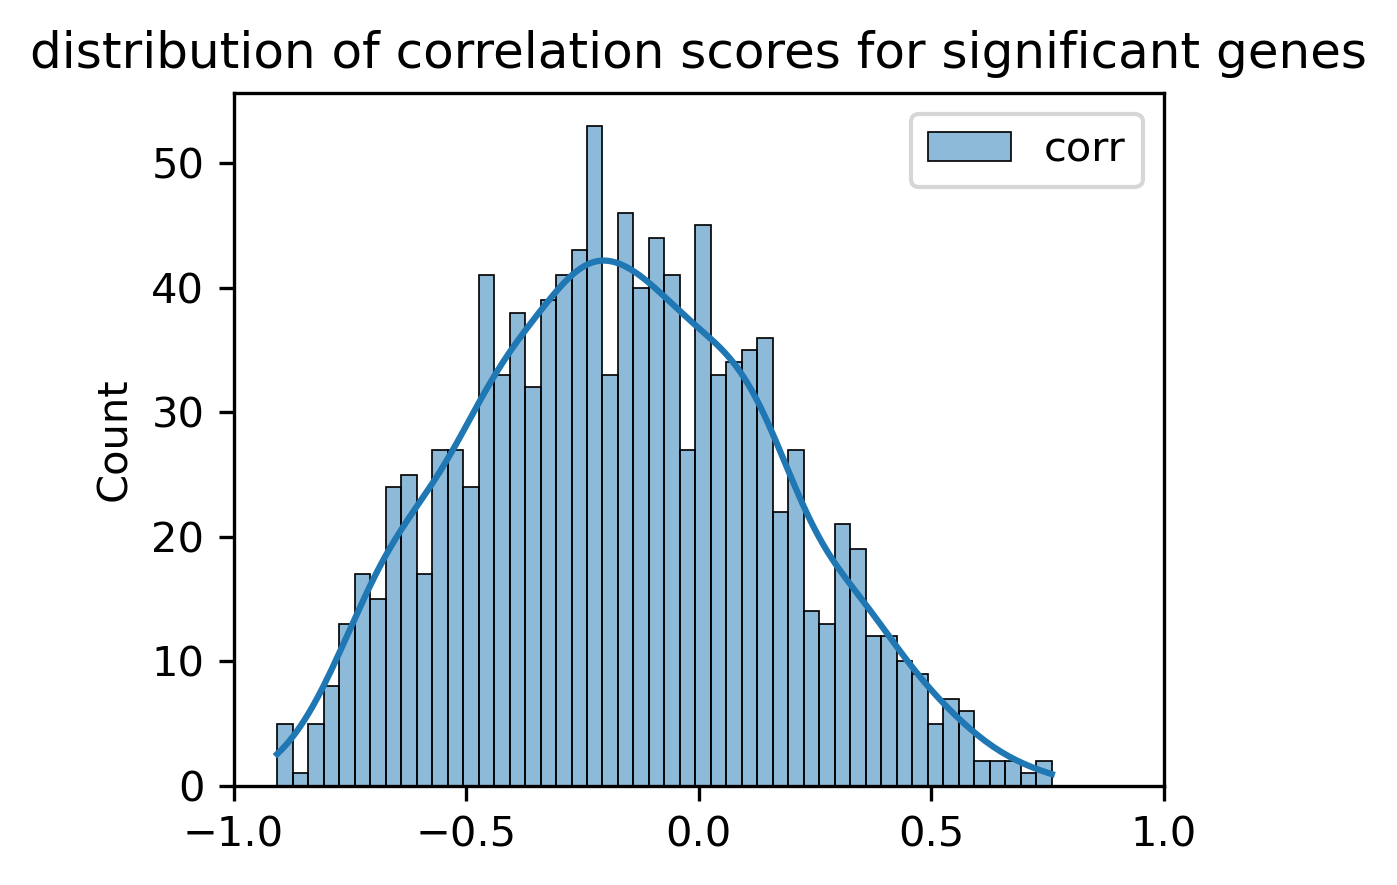

In [21]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

# Assuming corr_values is a numpy array or pandas Series with your correlation values
# corr_values = ...

# Create the plot
fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

# Plot the histogram with KDE
sns.histplot(corr_values, ax=ax, kde=True, bins=50, label='corr')

# Calculate mean and standard deviation for the normal distribution
data_mean = 0
data_std = corr_values.std()

# Generate x values for the normal distribution plot
x = np.linspace(-1, 1, 100)

# Generate y values using the normal distribution PDF
y = norm.pdf(x, data_mean, data_std)

# Normalize the normal distribution curve to match the histogram height
hist_height = np.histogram(corr_values, bins=50)[0].max()
y_scaled = y * hist_height / y.max()

# Plot the normal distribution curve
# ax.plot(x, y_scaled, 'r--', label='Normal distribution')

ax.set_title('distribution of correlation scores for significant genes')

# Set x-axis limits
ax.set_xlim(-1, 1)

# # Add legend
ax.legend()

# Show or save the figure
fig.savefig(f'/ceph/MethDev/pbio/kay/figures/0620_new_sig_mc_rna_correlation.pdf', bbox_inches='tight')
plt.show()


In [22]:
df = sig_gene_overlap_df
# Get the column names
columns = list(df.columns)

# Shuffle the columns
shuffled_columns = np.random.permutation(columns)

# Create a new DataFrame with shuffled columns while maintaining the order of values
shuffled_df = pd.DataFrame({columns[i]: df[shuffled_columns[i]].values for i in range(len(columns))})

# Print shuffled DataFrame
print("\nShuffled DataFrame:")
shuffled_df


Shuffled DataFrame:


,AT1G01550,AT1G02110,AT1G02260,AT1G03300,AT1G03445,AT1G03470,AT1G03940,AT1G04370,AT1G05020,AT1G05230,...,AT5G64000,AT5G64860,AT5G65010,AT5G66050,AT5G66310,AT5G66520,AT5G66815,AT5G67090,AT5G67340,AT5G67385
0,0.831315,0.101313,0.839053,0.487151,0.571155,0.313122,0.284177,0.142991,0.385228,0.283641,...,0.169781,0.048530,0.768029,0.097775,0.560611,0.128003,0.099199,0.083994,0.359825,0.066379
1,0.821740,0.096977,0.831752,0.510726,0.572104,0.304839,0.293146,0.150007,0.379562,0.300982,...,0.166185,0.030457,0.768259,0.097996,0.507650,0.111517,0.098928,0.080065,0.344010,0.062806
2,0.893246,0.126863,0.920914,0.643312,0.621324,0.328558,0.296648,0.138351,0.377204,0.252665,...,0.194111,0.059104,0.885877,0.078683,0.502945,0.119026,0.115965,0.128344,0.419936,0.073204
3,0.934897,0.052523,0.928393,0.504127,0.566047,0.136995,0.180995,0.087994,0.379334,0.299566,...,0.169102,0.049600,0.456943,0.079545,0.512765,0.073649,0.141922,0.017271,0.359801,0.063779
4,0.913287,0.115050,0.884763,0.494681,0.609158,0.333932,0.267035,0.154162,0.416425,0.271413,...,0.182282,0.031915,0.849843,0.115753,0.553275,0.122949,0.117560,0.108602,0.394718,0.054665
5,0.923902,0.041052,0.897361,0.582557,0.576660,0.161398,0.130240,0.104859,0.399921,0.278934,...,0.181285,0.067362,0.120810,0.070024,0.467489,0.021838,0.150805,0.016879,0.365008,0.081344
6,0.928919,0.084799,0.926864,0.500000,0.626315,0.360357,0.273965,0.169059,0.480415,0.322046,...,0.171253,0.016275,0.863061,0.109856,0.543624,0.145544,0.118252,0.091199,0.335404,0.061460
7,0.871724,0.098157,0.946341,0.541004,0.595989,0.317702,0.293864,0.147823,0.458450,0.293556,...,0.202532,0.113466,0.848617,0.067961,0.443652,0.116903,0.158038,0.057054,0.316129,0.100806
8,0.884615,0.087594,0.863158,0.547619,0.605213,0.358681,0.317345,0.121164,0.397388,0.258108,...,0.173788,0.018739,0.848790,0.130016,0.455102,0.122271,0.132728,0.077987,0.429587,0.063781
9,0.940299,0.090909,0.921053,0.616279,0.522727,0.358268,0.251220,0.171821,0.263374,0.472222,...,0.179916,0.008264,0.943396,0.082353,0.283333,0.136986,0.208955,0.065476,0.454545,0.048338


In [23]:
rand_corr_values = shuffled_df.corrwith(rna_by_cluster, axis =0).dropna()
rand_corr_values

AT1G01550   -0.256323
AT1G02110   -0.322442
AT1G02260    0.100056
AT1G03445   -0.194826
AT1G03470   -0.100929
               ...   
AT5G66310    0.118575
AT5G66815    0.183961
AT5G67090   -0.168729
AT5G67340    0.316847
AT5G67385    0.240676
Length: 1128, dtype: float64

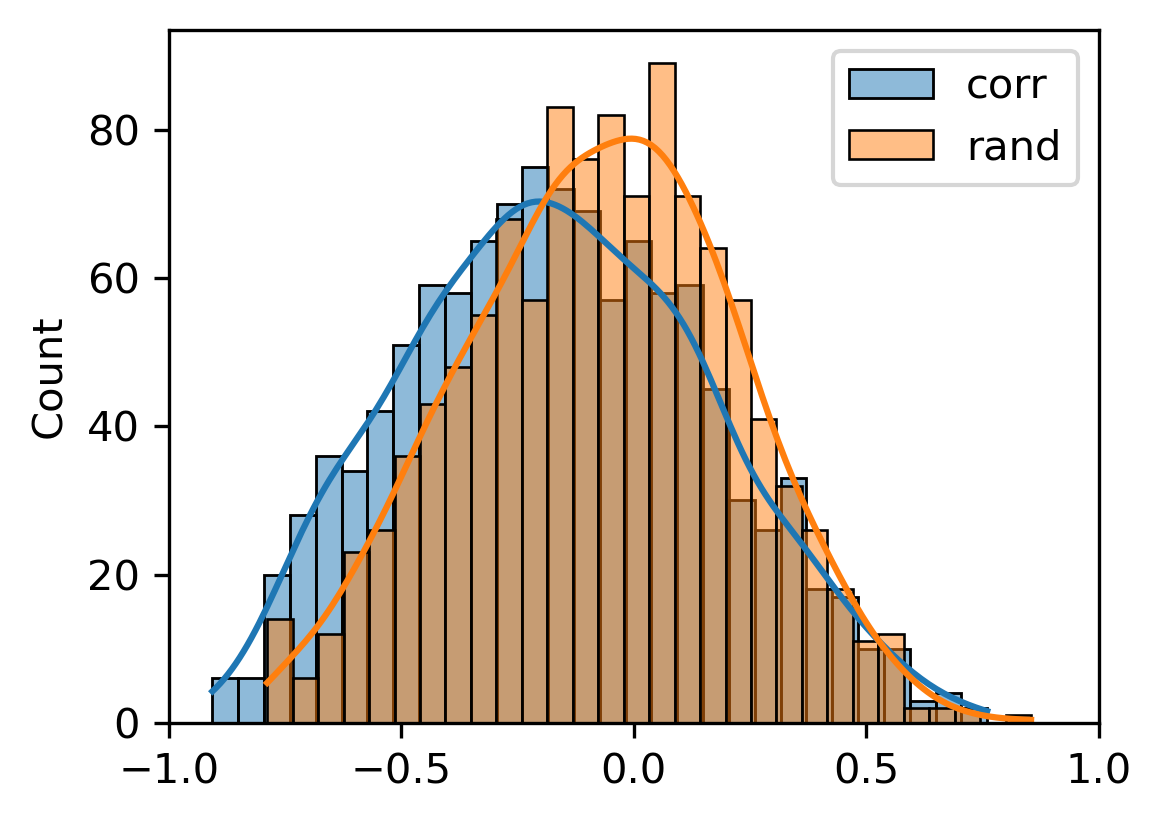

In [25]:

# Create the plot
fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

# Plot the histogram with KDE
sns.histplot(corr_values, ax=ax, kde=True, bins=30, label='corr')
sns.histplot(rand_corr_values, ax=ax, kde=True, bins=30, label='rand')

# Calculate mean and standard deviation for the normal distribution
data_mean = 0
data_std = corr_values.std()

# Generate x values for the normal distribution plot
x = np.linspace(-1, 1, 100)

# Generate y values using the normal distribution PDF
y = norm.pdf(x, data_mean, data_std)

# Normalize the normal distribution curve to match the histogram height
hist_height = np.histogram(corr_values, bins=50)[0].max()
y_scaled = y * hist_height / y.max()

# Plot the normal distribution curve
# ax.plot(x, y_scaled, 'r--', label='Normal distribution')

# Set x-axis limits
ax.set_xlim(-1, 1)

# Add legend
ax.legend()

# Show or save the figure
fig.savefig(f'/ceph/MethDev/pbio/kay/figures/0620_new_gene_rand_mc_rna_correlation.pdf', bbox_inches='tight')
plt.show()


In [26]:
ordered_corr = corr_values.sort_values(ascending = False)

In [27]:
pos = ordered_corr[:5]
pos.index

Index(['AT3G29770', 'AT4G02000', 'AT3G49800', 'AT1G77420', 'AT5G66050'], dtype='object')

In [28]:
neg = ordered_corr[-5:]
neg

AT3G55800   -0.880832
AT1G62030   -0.886872
AT5G18245   -0.888614
AT4G30400   -0.904946
AT2G33060   -0.906197
dtype: float64

In [29]:
sig_gene_overlap_df[pos.index]

gene,AT3G29770,AT4G02000,AT3G49800,AT1G77420,AT5G66050
cluster,,,,,
0.0,0.101250,0.590356,0.098297,0.072650,0.106960
1.0,0.126692,0.605889,0.098084,0.073721,0.102901
2.0,0.111578,0.641921,0.082885,0.080719,0.110513
3.0,0.145189,0.653986,0.095230,0.099828,0.084011
4.0,0.096820,0.574755,0.101832,0.092774,0.097161
5.0,0.130174,0.567723,0.102941,0.092695,0.082421
6.0,0.174898,0.681382,0.103261,0.091419,0.101404
7.0,0.188492,0.698006,0.101119,0.133303,0.115839
8.0,0.168586,0.575931,0.088947,0.101558,0.126293


In [30]:
rna_by_cluster[pos.index]

,AT3G29770,AT4G02000,AT3G49800,AT1G77420,AT5G66050
Cluster,,,,,
0,4.351494,0.822496,6.652021,1.688928,10.933216
1,3.318653,0.686528,19.222798,2.318653,47.126943
2,1.011628,0.558140,1.715116,1.357558,4.863372
3,4.894904,0.923567,13.235669,6.964968,17.117834
4,1.483283,0.048632,1.790274,2.501520,15.875380
5,1.005102,0.178571,11.714286,2.602041,8.831633
6,9.875706,2.107345,8.169492,7.841808,44.378531
7,7.101266,1.151899,4.917722,8.018987,21.348101
8,4.052632,1.601504,5.533835,4.030075,21.812030


In [31]:
rem_14_mc = sig_gene_overlap_df.loc[:13, :]

In [34]:
rem_14_rna = rna_by_cluster.loc[:13, :]
rem_14_rna

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01046,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,ATMG01380,ATMG01390,ATMG01400,ATMG01410,ATMG09450,ATMG09730,ATMG09740,ATMG09950,ATMG09960,ATMG09980
Cluster,,,,,,,,,,,,,,,,,,,,,
0,2.377856,30.949033,9.337434,51.249561,0.0,24.173989,236.629174,0.014060,15.038664,9.994728,...,0.022847,0.906854,0.003515,0.026362,0.0,0.0,0.005272,0.000000,0.007030,0.000000
1,3.427461,56.386010,16.386010,78.549223,0.0,48.961140,297.917098,0.233161,35.730570,12.906736,...,0.103627,1.093264,0.020725,0.025907,0.0,0.0,0.002591,0.000000,0.023316,0.015544
2,0.037791,15.168605,8.904070,27.770349,0.0,7.360465,63.476744,0.005814,7.709302,2.101744,...,0.046512,0.584302,0.000000,0.000000,0.0,0.0,0.203488,0.014535,0.008721,0.005814
3,0.929936,34.477707,5.878981,39.506369,0.0,6.152866,83.181529,0.038217,15.863057,9.687898,...,0.025478,1.082803,0.022293,0.006369,0.0,0.0,0.015924,0.000000,0.000000,0.003185
4,2.313070,41.820669,8.835866,32.340426,0.0,11.702128,93.541033,0.048632,14.635258,4.176292,...,0.015198,0.787234,0.006079,0.003040,0.0,0.0,0.006079,0.000000,0.003040,0.003040
5,0.647959,17.770408,0.464286,34.061224,0.0,4.556122,71.239796,0.974490,5.683673,10.770408,...,0.010204,0.591837,0.045918,0.000000,0.0,0.0,0.071429,0.000000,0.005102,0.015306
6,1.361582,67.073446,3.627119,26.548023,0.0,26.491525,86.350282,0.045198,37.610169,16.655367,...,0.101695,1.406780,0.022599,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.062147
7,11.107595,33.322785,4.727848,32.734177,0.0,16.993671,68.582278,5.284810,5.677215,8.139241,...,0.018987,1.424051,0.012658,0.012658,0.0,0.0,0.037975,0.000000,0.006329,0.006329
8,0.917293,44.932331,10.789474,42.120301,0.0,5.676692,78.849624,0.045113,11.548872,8.924812,...,0.037594,0.518797,0.037594,0.037594,0.0,0.0,0.060150,0.090226,0.015038,0.015038


In [35]:
corr_rm_14 = rem_14_mc.corrwith(rem_14_rna, axis =0).dropna()
corr_rm_14

AT1G01550   -0.224281
AT1G02110   -0.766001
AT1G02260    0.040398
AT1G03445    0.060772
AT1G03470    0.290930
               ...   
AT5G66310    0.276550
AT5G66815   -0.229401
AT5G67090   -0.134194
AT5G67340   -0.507050
AT5G67385   -0.297238
Length: 1128, dtype: float64

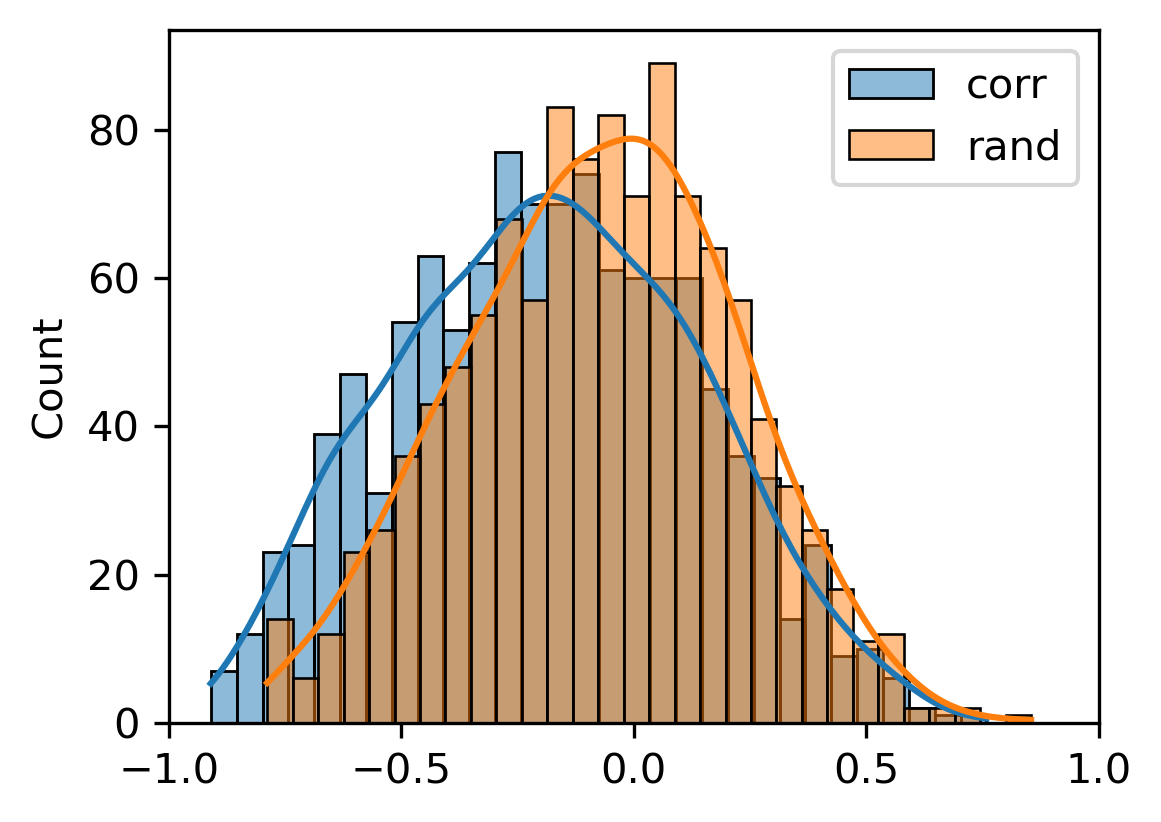

In [36]:

# Create the plot
fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

# Plot the histogram with KDE
sns.histplot(corr_rm_14, ax=ax, kde=True, bins=30, label='corr')
sns.histplot(rand_corr_values, ax=ax, kde=True, bins=30, label='rand')

# Calculate mean and standard deviation for the normal distribution
data_mean = 0
data_std = corr_values.std()

# Generate x values for the normal distribution plot
x = np.linspace(-1, 1, 100)

# Generate y values using the normal distribution PDF
y = norm.pdf(x, data_mean, data_std)

# Normalize the normal distribution curve to match the histogram height
hist_height = np.histogram(corr_values, bins=50)[0].max()
y_scaled = y * hist_height / y.max()

# Plot the normal distribution curve
# ax.plot(x, y_scaled, 'r--', label='Normal distribution')

# Set x-axis limits
ax.set_xlim(-1, 1)

# Add legend
ax.legend()

# Show or save the figure
fig.savefig(f'/ceph/MethDev/pbio/kay/figures/0620_new_gene_rand_mc_rna_correlation_rem_14.pdf', bbox_inches='tight')
plt.show()


In [37]:
len(corr_rm_14.values>0.5)

1128

In [38]:
len(corr_rm_14<-0.5)

1128

In [39]:
len(corr_rm_14[corr_rm_14>0.5])

18

In [40]:
corr_rm_14[corr_rm_14<-0.5]

AT1G02110   -0.766001
AT1G03940   -0.674610
AT1G05620   -0.556003
AT1G06690   -0.655865
AT1G08510   -0.717946
               ...   
AT5G61070   -0.633297
AT5G61270   -0.520550
AT5G63980   -0.691431
AT5G65010   -0.687750
AT5G67340   -0.507050
Length: 197, dtype: float64

In [41]:
len(corr_values[corr_values>0.5])

26

In [42]:
len(corr_values[corr_values<-0.5])

189

In [43]:
thres = -0.5
below_threshold = corr_rm_14[corr_rm_14<=thres]
below_threshold

AT1G02110   -0.766001
AT1G03940   -0.674610
AT1G05620   -0.556003
AT1G06690   -0.655865
AT1G08510   -0.717946
               ...   
AT5G61070   -0.633297
AT5G61270   -0.520550
AT5G63980   -0.691431
AT5G65010   -0.687750
AT5G67340   -0.507050
Length: 197, dtype: float64

In [44]:
rem_14_neg_mc = rem_14_mc[corr_rm_14[corr_rm_14<-0.5].index]
rem_14_neg_mc

gene,AT1G02110,AT1G03940,AT1G05620,AT1G06690,AT1G08510,AT1G09160,AT1G11785,AT1G11860,AT1G13130,AT1G19350,...,AT5G53450,AT5G53970,AT5G54040,AT5G57710,AT5G60210,AT5G61070,AT5G61270,AT5G63980,AT5G65010,AT5G67340
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,0.192462,0.067028,0.056082,0.093014,0.095736,0.060198,0.588336,0.056583,0.048826,0.118220,...,0.303481,0.114418,0.352579,0.150948,0.235145,0.144683,0.080340,0.192314,0.165718,0.173586
1.0,0.173191,0.048140,0.057386,0.083976,0.085806,0.065128,0.484386,0.049951,0.040170,0.110777,...,0.246906,0.098045,0.292368,0.145529,0.219281,0.144365,0.086504,0.174659,0.111238,0.166137
2.0,0.188358,0.065815,0.063785,0.106792,0.105917,0.053329,0.630769,0.101587,0.049622,0.114742,...,0.322305,0.140107,0.386479,0.157763,0.236445,0.226791,0.069797,0.203070,0.188239,0.171446
3.0,0.054003,0.037233,0.019740,0.130747,0.059625,0.168404,0.416787,0.207052,0.029044,0.105575,...,0.247402,0.179362,0.313604,0.107985,0.178834,0.228930,0.071540,0.210255,0.185304,0.215736
4.0,0.202826,0.074032,0.064257,0.095213,0.091047,0.064784,0.541582,0.069010,0.054209,0.119183,...,0.259536,0.122558,0.311707,0.129571,0.248814,0.172115,0.115256,0.209343,0.187799,0.182915
5.0,0.023550,0.049417,0.015630,0.129263,0.052239,0.153360,0.329670,0.216082,0.024198,0.116978,...,0.307172,0.191549,0.286986,0.103718,0.161272,0.220386,0.044855,0.213516,0.229267,0.235652
6.0,0.180348,0.053737,0.069429,0.095291,0.109131,0.073563,0.448161,0.116019,0.038179,0.088427,...,0.218208,0.123441,0.322395,0.135524,0.250678,0.210273,0.115664,0.153101,0.131541,0.171282
7.0,0.192500,0.060938,0.050906,0.155677,0.080019,0.172638,0.560606,0.220420,0.042476,0.139449,...,0.391339,0.187656,0.223864,0.107931,0.214321,0.219289,0.097754,0.172442,0.204042,0.176656
8.0,0.191176,0.049194,0.059736,0.098039,0.089400,0.120104,0.540541,0.147959,0.053094,0.093847,...,0.250763,0.179434,0.320190,0.136227,0.215896,0.200813,0.083067,0.109268,0.174987,0.140805


In [45]:
df_zscore = rem_14_neg_mc.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
df_zscore

gene,AT1G02110,AT1G03940,AT1G05620,AT1G06690,AT1G08510,AT1G09160,AT1G11785,AT1G11860,AT1G13130,AT1G19350,...,AT5G53450,AT5G53970,AT5G54040,AT5G57710,AT5G60210,AT5G61070,AT5G61270,AT5G63980,AT5G65010,AT5G67340
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,0.283131,0.414651,0.034093,-0.646636,0.623461,-0.998239,0.460713,-1.034602,0.940625,0.211340,...,0.383586,-1.129048,0.972382,0.640081,0.540844,-1.306000,-0.114650,0.309558,-0.045551,0.074735
1.0,-0.019840,-0.862346,0.110584,-1.056477,-0.014222,-0.888423,-0.514198,-1.127157,0.176111,-0.196103,...,-0.706197,-1.564666,-0.415869,0.387116,-0.006579,-1.312808,0.190926,-0.164783,-1.358374,-0.158533
2.0,0.218609,0.332643,0.485949,-0.021798,1.277303,-1.151262,0.858679,-0.406463,1.010909,0.020944,...,0.746199,-0.445554,1.753997,0.958252,0.585705,0.452754,-0.637275,0.598537,0.497143,0.007738
3.0,-1.893666,-1.599737,-2.097641,1.064483,-1.695633,1.412283,-1.148187,1.065532,-0.806638,-0.480864,...,-0.696641,0.598903,0.073761,-1.365694,-1.402302,0.498570,-0.550887,0.791578,0.426437,1.394834
4.0,0.446065,0.888163,0.513628,-0.546902,0.322373,-0.896066,0.022223,-0.861147,1.416136,0.264029,...,-0.462908,-0.912471,0.030032,-0.357928,1.012524,-0.718422,1.616222,0.767073,0.486549,0.366911
5.0,-2.372436,-0.775970,-2.338711,0.997218,-2.169978,1.077133,-1.965229,1.191573,-1.234709,0.143304,...,0.454698,0.923175,-0.539952,-1.564906,-2.008322,0.315543,-1.873691,0.879206,1.485820,2.018594
6.0,0.092680,-0.483925,0.817019,-0.543358,1.483754,-0.700500,-0.853948,-0.205031,0.000171,-1.419509,...,-1.259004,-0.888974,0.276441,-0.080007,1.076876,0.098934,1.636407,-0.743993,-0.869127,0.002601
7.0,0.283728,0.002932,-0.269532,2.195018,-0.385880,1.506607,0.200642,1.252118,0.379792,1.373335,...,2.075996,0.819583,-1.995335,-1.368236,-0.177725,0.292052,0.748612,-0.224340,0.877971,0.170903
8.0,0.262920,-0.791107,0.248425,-0.418734,0.216556,0.336303,0.012454,0.240760,1.317635,-1.122823,...,-0.631900,0.600828,0.225621,-0.047178,-0.123397,-0.103709,0.020545,-1.921654,0.177815,-0.951932


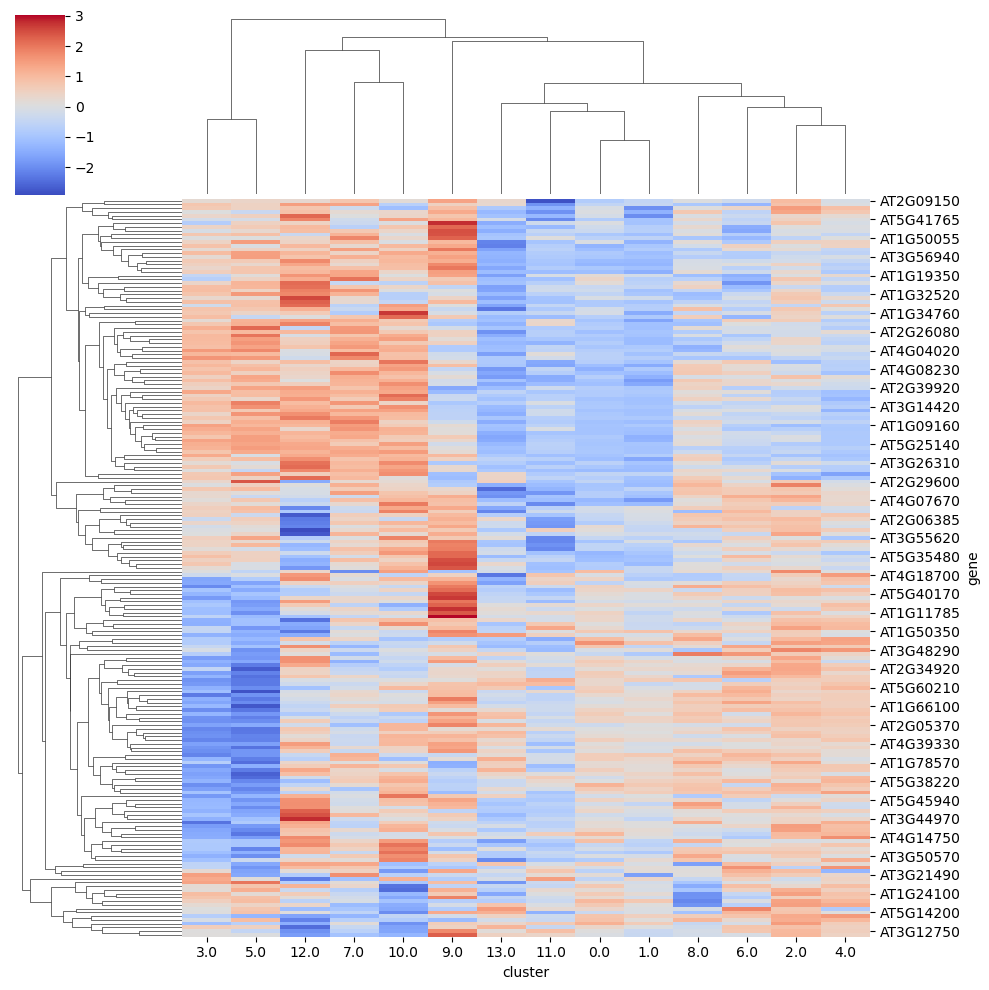

In [50]:
cluster = sns.clustermap(df_zscore.T, method='average', metric='euclidean', cmap='coolwarm', figsize=(10, 10))

# plt.title(f'Most Differentially Methylated Genes Clustermap')
plt.savefig('/ceph/MethDev/pbio/kay/figures/0620_highMCClusterMap.pdf')
plt.show()

In [51]:
rna_by_cluster[below_threshold.index]

,AT1G02110,AT1G03940,AT1G05620,AT1G06690,AT1G08510,AT1G09160,AT1G11785,AT1G11860,AT1G13130,AT1G19350,...,AT5G53450,AT5G53970,AT5G54040,AT5G57710,AT5G60210,AT5G61070,AT5G61270,AT5G63980,AT5G65010,AT5G67340
Cluster,,,,,,,,,,,,,,,,,,,,,
0,2.133568,4.959578,0.520211,69.054482,76.123023,31.031634,12.138840,88.384886,0.010545,66.594025,...,239.599297,60.906854,0.007030,29.326889,0.920914,2.850615,92.284710,2.416520,15.646749,0.042179
1,2.178756,8.823834,1.305699,67.067358,158.360104,53.367876,32.437824,187.717617,0.020725,161.984456,...,875.354922,90.295337,0.012953,54.911917,0.528497,1.404145,95.331606,4.020725,31.538860,0.323834
2,0.514535,3.988372,1.244186,10.555233,36.933140,21.279070,1.502907,35.712209,0.002907,19.651163,...,116.296512,14.851744,0.043605,21.348837,0.738372,0.000000,22.558140,1.244186,7.133721,2.508721
3,3.044586,6.984076,8.156051,11.977707,222.143312,21.789809,29.159236,33.968153,0.015924,49.843949,...,183.394904,9.363057,0.015924,145.920382,19.671975,0.216561,118.350318,4.312102,9.894904,2.022293
4,1.267477,1.075988,1.209726,25.987842,39.200608,31.343465,8.583587,89.905775,0.015198,40.772036,...,338.972644,31.945289,0.009119,13.343465,0.091185,0.841945,34.911854,1.346505,21.033435,0.109422
5,4.275510,2.341837,3.346939,13.959184,237.433673,21.178571,39.102041,35.035714,0.010204,60.326531,...,172.454082,14.015306,0.086735,175.510204,24.250000,0.020408,256.163265,2.734694,6.178571,1.316327
6,0.768362,11.926554,2.412429,39.700565,82.231638,70.203390,17.050847,98.683616,0.000000,241.666667,...,627.231638,41.508475,0.022599,51.745763,0.220339,1.514124,21.700565,4.824859,60.214689,0.033898
7,1.373418,5.784810,3.063291,7.886076,125.424051,24.101266,11.708861,29.278481,0.000000,28.025316,...,94.107595,12.715190,1.474684,26.202532,0.310127,0.012658,16.645570,0.949367,7.037975,4.550633
8,1.533835,10.075188,2.812030,15.774436,65.947368,31.834586,7.924812,40.939850,0.000000,48.451128,...,230.248120,14.571429,0.000000,7.541353,0.466165,0.030075,11.616541,12.932331,16.639098,2.052632


In [52]:
gene_order = cluster.dendrogram_row.reordered_ind
seurat_order = cluster.dendrogram_col.reordered_ind
thres_rna_df = rna_by_cluster[below_threshold.index]#.drop(columns=[2.0,9.0], axis = 0)
thres_rna_df_reordered = thres_rna_df.iloc[seurat_order,gene_order]

In [53]:
thres_rna_df

,AT1G02110,AT1G03940,AT1G05620,AT1G06690,AT1G08510,AT1G09160,AT1G11785,AT1G11860,AT1G13130,AT1G19350,...,AT5G53450,AT5G53970,AT5G54040,AT5G57710,AT5G60210,AT5G61070,AT5G61270,AT5G63980,AT5G65010,AT5G67340
Cluster,,,,,,,,,,,,,,,,,,,,,
0,2.133568,4.959578,0.520211,69.054482,76.123023,31.031634,12.138840,88.384886,0.010545,66.594025,...,239.599297,60.906854,0.007030,29.326889,0.920914,2.850615,92.284710,2.416520,15.646749,0.042179
1,2.178756,8.823834,1.305699,67.067358,158.360104,53.367876,32.437824,187.717617,0.020725,161.984456,...,875.354922,90.295337,0.012953,54.911917,0.528497,1.404145,95.331606,4.020725,31.538860,0.323834
2,0.514535,3.988372,1.244186,10.555233,36.933140,21.279070,1.502907,35.712209,0.002907,19.651163,...,116.296512,14.851744,0.043605,21.348837,0.738372,0.000000,22.558140,1.244186,7.133721,2.508721
3,3.044586,6.984076,8.156051,11.977707,222.143312,21.789809,29.159236,33.968153,0.015924,49.843949,...,183.394904,9.363057,0.015924,145.920382,19.671975,0.216561,118.350318,4.312102,9.894904,2.022293
4,1.267477,1.075988,1.209726,25.987842,39.200608,31.343465,8.583587,89.905775,0.015198,40.772036,...,338.972644,31.945289,0.009119,13.343465,0.091185,0.841945,34.911854,1.346505,21.033435,0.109422
5,4.275510,2.341837,3.346939,13.959184,237.433673,21.178571,39.102041,35.035714,0.010204,60.326531,...,172.454082,14.015306,0.086735,175.510204,24.250000,0.020408,256.163265,2.734694,6.178571,1.316327
6,0.768362,11.926554,2.412429,39.700565,82.231638,70.203390,17.050847,98.683616,0.000000,241.666667,...,627.231638,41.508475,0.022599,51.745763,0.220339,1.514124,21.700565,4.824859,60.214689,0.033898
7,1.373418,5.784810,3.063291,7.886076,125.424051,24.101266,11.708861,29.278481,0.000000,28.025316,...,94.107595,12.715190,1.474684,26.202532,0.310127,0.012658,16.645570,0.949367,7.037975,4.550633
8,1.533835,10.075188,2.812030,15.774436,65.947368,31.834586,7.924812,40.939850,0.000000,48.451128,...,230.248120,14.571429,0.000000,7.541353,0.466165,0.030075,11.616541,12.932331,16.639098,2.052632


In [54]:
thres_rna_df.iloc[seurat_order,gene_order]

,AT2G09150,AT4G35300,AT1G57590,AT4G13450,AT5G04950,AT5G41765,AT3G14950,AT3G12670,AT5G41670,AT1G23310,...,AT2G14750,AT3G43430,AT3G04535,AT5G14200,AT1G22720,AT5G17740,AT3G01120,AT5G35670,AT3G12750,AT5G17510
Cluster,,,,,,,,,,,,,,,,,,,,,
3,0.006369,29.929936,12.500000,0.035032,3.140127,0.073248,0.095541,10.573248,22.500000,153.557325,...,13.312102,0.076433,0.025478,1.407643,0.015924,0.028662,7.095541,10.289809,0.009554,13.579618
5,0.000000,14.938776,3.673469,0.025510,0.464286,0.015306,0.035714,7.255102,26.494898,112.397959,...,14.020408,2.301020,0.051020,0.397959,0.030612,0.020408,5.627551,6.515306,1.015306,29.188776
12,0.000000,2.549020,6.372549,0.000000,8.647059,0.000000,0.000000,13.529412,51.156863,128.529412,...,44.647059,0.137255,0.000000,19.568627,0.098039,0.117647,6.549020,20.117647,5.274510,37.666667
7,0.000000,36.443038,16.664557,0.044304,0.392405,0.037975,0.031646,18.265823,31.303797,128.949367,...,22.588608,8.189873,0.215190,6.886076,0.031646,0.000000,7.101266,6.987342,5.411392,22.424051
10,0.012987,29.675325,8.701299,0.051948,24.350649,0.077922,0.000000,15.623377,32.116883,130.623377,...,320.545455,9.324675,0.233766,107.779221,0.038961,0.025974,22.896104,4.233766,10.844156,14.220779
9,0.000000,6.702128,3.159574,0.000000,4.478723,0.000000,0.000000,1.244681,13.361702,70.053191,...,2.319149,0.106383,0.010638,0.000000,0.000000,0.000000,1.882979,1.574468,0.000000,0.446809
13,0.000000,42.360000,22.880000,0.080000,4.040000,0.120000,0.160000,6.960000,55.240000,1199.400000,...,61.000000,0.080000,0.000000,0.000000,0.000000,0.040000,2.800000,4.360000,0.000000,11.480000
11,0.051282,69.461538,77.525641,0.012821,50.435897,0.128205,0.076923,13.576923,25.910256,544.115385,...,28.589744,0.205128,0.000000,0.833333,0.000000,0.000000,3.897436,22.089744,0.076923,23.589744
0,0.014060,64.107206,42.806678,0.022847,4.724077,0.028120,0.045694,13.616872,27.316344,519.532513,...,6.428822,0.068541,0.000000,2.852373,0.014060,0.012302,5.745167,4.228471,0.008787,29.186292


In [55]:
thres_rna_df_reordered_log = thres_rna_df_reordered.applymap(lambda x: np.log2(x + 1e-9))  # Adding a small value to avoid log(0)

In [56]:
rna_zscore_log = thres_rna_df_reordered_log.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
# rna_zscore

In [57]:
rna_zscore = thres_rna_df_reordered.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
# rna_zscore

TypeError: 'str' object is not callable

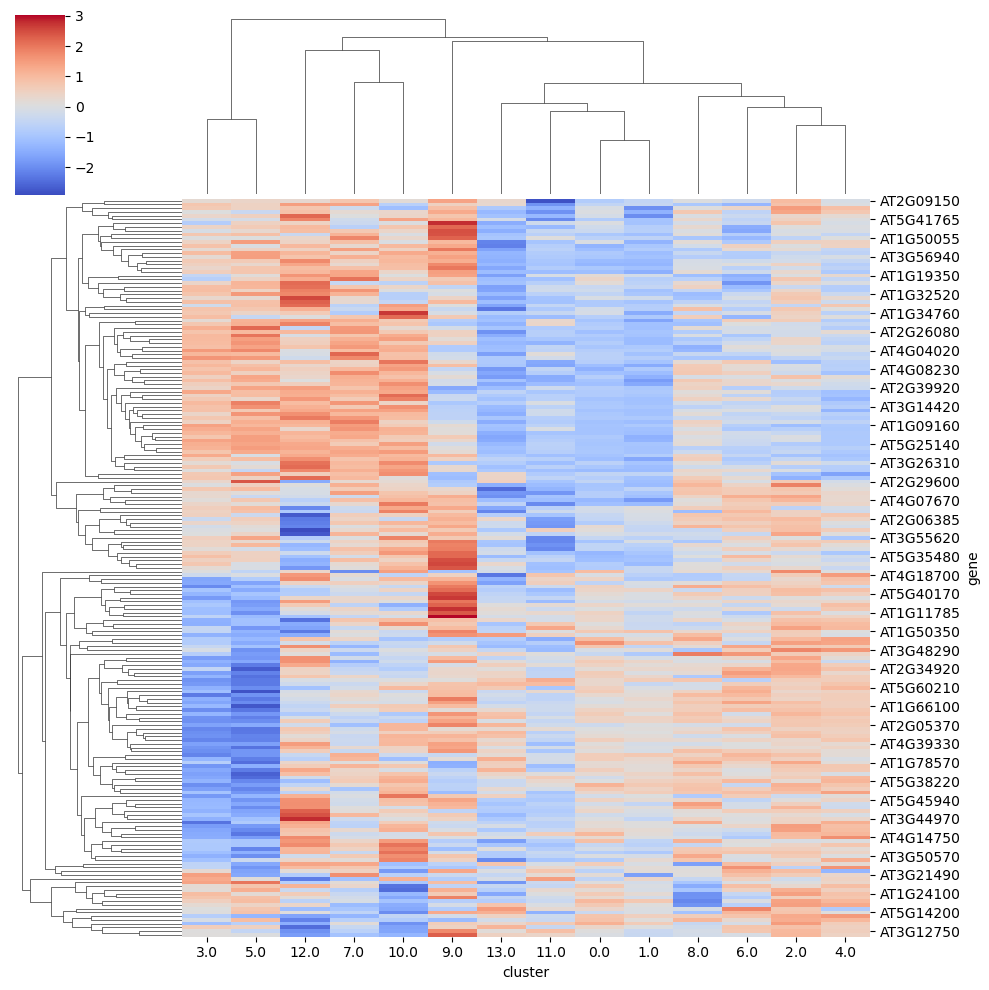

In [58]:
cluster = sns.clustermap(df_zscore.T, method='average', metric='euclidean', cmap='coolwarm', figsize=(10, 10))

plt.title(f'Most Differentially Methylated Genes Clustermap')
# plt.savefig('/ceph/MethDev/pbio/kay/result/highMCClusterMap.pdf')
plt.show()

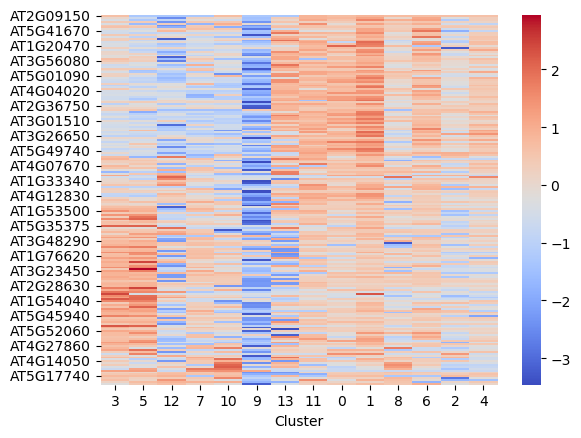

In [61]:
sns.heatmap(rna_zscore_log.T,cmap = 'coolwarm')
plt.savefig('/ceph/MethDev/pbio/kay/figures/0620_highMCRNAClusterMap.pdf')

<AxesSubplot:xlabel='Cluster'>

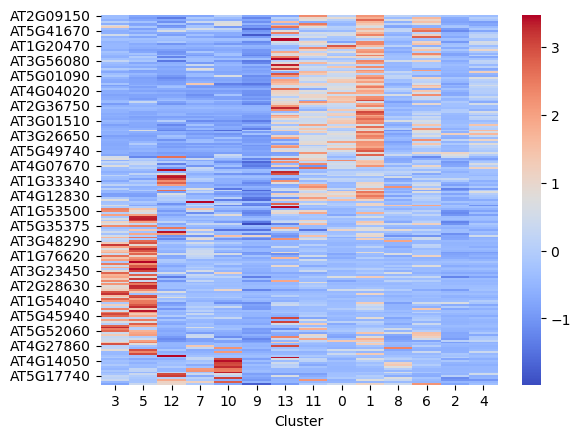

In [60]:
sns.heatmap(rna_zscore.T,cmap = 'coolwarm')
